**Trainer Notebook**

Load Libraries and Dataset

In [ ]:
# Step 1 - importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Step 2 - Load Dataset
df = pd.read_csv('https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/regression/salary_data.csv')
df

,Experience,Salary
0,5.0,90000.0
1,3.0,65000.0
2,15.0,150000.0
3,7.0,60000.0
4,20.0,200000.0
...,...,...
370,8.0,85000.0
371,19.0,170000.0
372,2.0,40000.0
373,7.0,90000.0


EDA

In [ ]:
#Task 3 - EDA
df.head()

,Experience,Salary
0,5.0,90000.0
1,3.0,65000.0
2,15.0,150000.0
3,7.0,60000.0
4,20.0,200000.0


In [ ]:
df.tail()

,Experience,Salary
370,8.0,85000.0
371,19.0,170000.0
372,2.0,40000.0
373,7.0,90000.0
374,15.0,150000.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Experience  373 non-null    float64
 1   Salary      373 non-null    float64
dtypes: float64(2)
memory usage: 6.0 KB


In [ ]:
df.describe()

,Experience,Salary
count,373.000000,373.000000
mean,10.030831,100577.345845
std,6.557007,48240.013482
min,0.000000,350.000000
25%,4.000000,55000.000000
50%,9.000000,95000.000000
75%,15.000000,140000.000000
max,25.000000,250000.000000


In [ ]:
df.corr()

,Experience,Salary
Experience,1.000000,0.930338
Salary,0.930338,1.000000


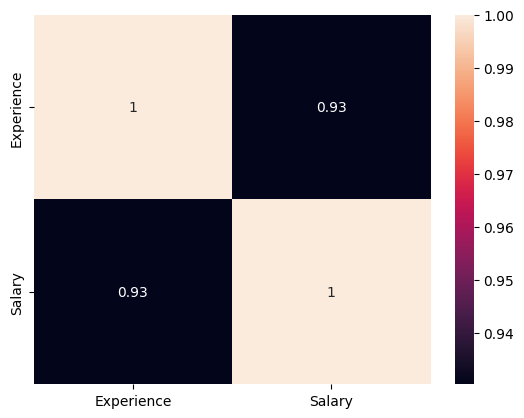

In [ ]:
import matplotlib.pyplot as plt
sns.heatmap(df.corr(), annot=True)
plt.show()


Preprocessing

In [ ]:
#Check null values / Empty Cells in each column
df.isnull().sum()

,0
Experience,2
Salary,2


In [ ]:
df.isna().sum()

,0
Experience,2
Salary,2


In [ ]:
#Null values present - So apply Dropping
#Dropping
df.dropna(inplace=True)
df

,Experience,Salary
0,5.0,90000.0
1,3.0,65000.0
2,15.0,150000.0
3,7.0,60000.0
4,20.0,200000.0
...,...,...
370,8.0,85000.0
371,19.0,170000.0
372,2.0,40000.0
373,7.0,90000.0


In [ ]:
#View duplicates
df.duplicated().sum()
# df.drop_duplicates(inplace=True)
# We do not remove duplicates since there more duplicates, removing them will reduce dataset size

np.int64(219)

{'whiskers': [<matplotlib.lines.Line2D at 0x7b5c68bd9340>,
 'caps': [<matplotlib.lines.Line2D at 0x7b5c68b78e90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b5c68b77800>],
 'medians': [<matplotlib.lines.Line2D at 0x7b5c68b7b530>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b5c68b79a60>],
 'means': []}

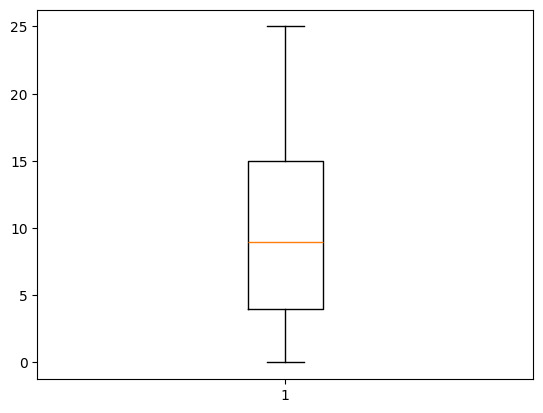

In [ ]:
# Checking Outliers
plt.boxplot(df['Experience'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7b5c6937d940>,
 'caps': [<matplotlib.lines.Line2D at 0x7b5c68d178f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b5c6937e750>],
 'medians': [<matplotlib.lines.Line2D at 0x7b5c68a58050>],
 'fliers': [<matplotlib.lines.Line2D at 0x7b5c68a58380>],
 'means': []}

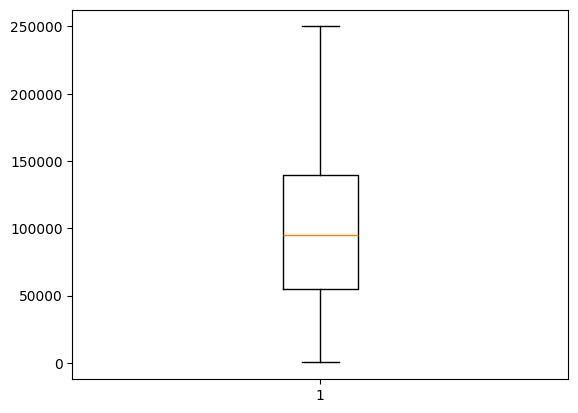

In [ ]:
plt.boxplot(df['Salary'])

In [ ]:
#No outliers in Experience, Salary
#Outlier Removal  -  not required, there is no outliers
#Label Encoding -  not required
#Scaling -  not required

Train Test Split

In [ ]:

from sklearn.model_selection import train_test_split #function
# Define X,y
# X = df[['Experience']]
# y = df['Salary']
X= df.drop('Salary', axis=1)
y = df['Salary']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(df.shape)
print(X.shape)
print(y.shape)
#20% Testing 75, Training (80%): 298
print(X_train.shape) #298x1
print(y_train.shape) #298x1
print(X_test.shape)  #75x1
print(y_test.shape)  #75x1
#

(373, 2)
(373, 1)
(373,)
(298, 1)
(298,)
(75, 1)
(75,)


Model Selection & Training

In [ ]:
#Model: Linear Regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
X_test

,Experience
329,21.0
33,10.0
15,16.0
316,6.0
57,17.0
...,...
94,7.0
196,11.0
313,4.0
294,14.0


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test) #answersheet
y_pred

array([174795.47129497,  99746.97937009, 140682.52042002,  72456.61867014,
       147505.11059501, 154327.70077   , 181618.06146996,  99746.97937009,
        51988.84814517,  92924.3891951 , 120214.74989506, 174795.47129497,
        45166.25797018,  92924.3891951 , 127037.34007005,  51988.84814517,
        65634.02849515,  41754.96288269,  79279.20884513,  86101.79902012,
        99746.97937009,  92924.3891951 , 140682.52042002,  65634.02849515,
        72456.61867014,  58811.43832016, 154327.70077   ,  45166.25797018,
       120214.74989506, 161150.29094499,  51988.84814517, 127037.34007005,
        51988.84814517, 133859.93024504,  99746.97937009,  34932.3727077 ,
       174795.47129497,  45166.25797018, 154327.70077   ,  58811.43832016,
        45166.25797018,  92924.3891951 , 202085.83199492, 161150.29094499,
        45166.25797018, 140682.52042002, 106569.56954508,  45166.25797018,
        45166.25797018,  45166.25797018, 161150.29094499,  86101.79902012,
       120214.74989506, 1

In [ ]:
y_test

,Salary
329,180000.0
33,65000.0
15,125000.0
316,80000.0
57,140000.0
...,...
94,75000.0
196,90000.0
313,60000.0
294,140000.0


In [ ]:
# -5 -2 4 3
# TOTAL EROOR = 0
# ABOLSUTE ERROR 5 2 4 3
#Total Absolute Error
#Mean Absolute Error : MAE
# 25 4 16 9
# Total Squared Error
# Mean Squared Error : MSE
# RMSE : Root Mean Squared Error
#R2 Score

Model Evaluation

In [ ]:
# 10 - 11  = Error = abs|-1| = 1  = y1 - y^1
# 15 - 14  = Error = abs +1 = y2 - y^2
# 9  - 11    Errp = |-2| = 2 = y3 - y^3
# 8  - 6    -=      = abs 2 = y4 - y^4

#Sum(|yi - y^i|)/n

# Total Error = -1 + 1 -2 + 2 = 0
# Total Absoulute Error = 1 + 1 +2 + 2 = 6
#Means Absoulute Error = 6/4  MAE

# -ve to +ve
# 10 - 11  = Error = sqare(-1) = 1
# 15 - 14  = Error = sqare( +1) = 1
# 9  - 11    Errp =sqare(-2) = 4
# 8  - 6    -=      = sqare( -2) = 4
# Total Square Error = 1 + 1 +4 +4 = 10
# Mean Squared Error = 10/4  MSE
# Root Mean Squared Error = sqrt(MSE) =

In [ ]:
from sklearn.metrics import mean_absolute_error
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')


Mean Absolute Error: 12094.170341194764


In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred) #answer key, answersheet - evaluate
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 241834883.8999349


In [ ]:
from sklearn.metrics import root_mean_squared_error
# Evaluate the model
rmse =root_mean_squared_error(y_test, y_pred)
print(f'Root Mean Squared Error: {rmse}')

Root Mean Squared Error: 15551.041248094447


In [ ]:
from sklearn.metrics import r2_score
# Evaluate the model using R-squared
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

R-squared: 0.8991338517367767


In [ ]:
# Extract coefficients
slope = model.coef_
intercept = model.intercept_

# Display intercepts
print(f'Slope: {slope}')
print(f'Y-Intercept: {intercept}')
print(f'X-Intercept: {-intercept/slope}')

Slope: [6822.59017499]
Y-Intercept: 31521.077620206008
X-Intercept: [-4.62010421]


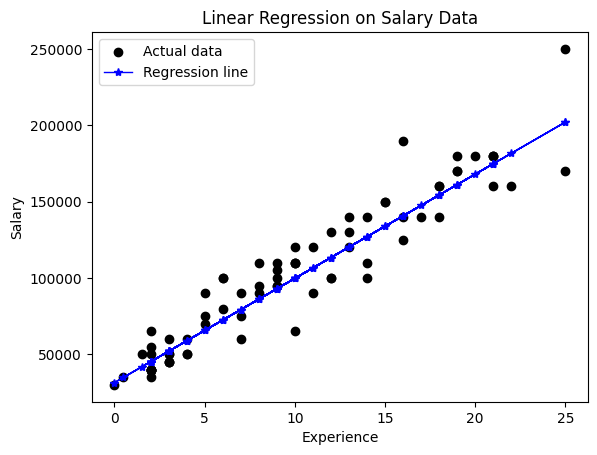

In [ ]:
# Plot the original data and the regression line
plt.scatter(X_test, y_test, color='black', label='Actual data')
plt.plot(X_test, y_pred, color='blue', linewidth=1, label='Regression line',marker='*')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Linear Regression on Salary Data')
plt.legend()
plt.show()